The Blood-brain barrier penetration (BBBP)
--------------------------------------------------------------

### All libraries we need

In [1]:
import os
import os.path as osp
import shutil
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import copy
import time
from utils import *


import torch
import torch.nn as nn
from torch.optim import Adam

#********************************************************#
'''
load_dataset contain lots of functions for loading several datasets and 
also there is a function as name get_ dataloader for generating a
dictionary of training, validation, and testing dataLoader.
'''
from load_dataset import get_dataset, get_dataloader

#********************************************************#
'''
As we need several arguments for training process, we store all argument in configure file. 
For using this file, you need the library'Typed Argument Parser (Tap). So you need 'pip install typed-argument-parser'. 
'''
from Configures import data_args, train_args, model_args

### start loading data

In [8]:
print(data_args.dataset_name)
print(data_args.dataset_dir)



bbbp
/datasets


In [3]:
dataset = get_dataset(data_args.dataset_dir, data_args.dataset_name)
input_dim = dataset.num_node_features
output_dim = int(dataset.num_classes)


print(input_dim)
print(output_dim)

9
2


### Data Analysis

In [9]:
avg_nodes = 0.0
avg_edge_index = 0.0
for i in range(len(dataset)):
    avg_nodes += dataset[i].x.shape[0]
    avg_edge_index += dataset[i].edge_index.shape[1]
avg_nodes /= len(dataset)
avg_edge_index /= len(dataset)
print(f"graphs {len(dataset)}, avg_nodes{avg_nodes :.4f}, avg_edge_index_{avg_edge_index/2 :.4f}")

best_acc = 0.0
data_size = len(dataset)
print(f'The total num of dataset is {data_size}')



graphs 2050, avg_nodes23.9356, avg_edge_index_25.8151
The total num of dataset is 2050


In [10]:


# Read the CSV file
df = pd.read_csv('datasets/bbbp/raw/BBBP.csv')

# Print the shape of the dataset
print("The shape of the dataset is:", df.shape)

# Print the columns of the dataset
print("The columns of the dataset are:", df.columns)

# Print the summary statistics of the dataset
print("The summary statistics of the dataset are:")
print(df.describe())

# Print some sample rows of the dataset
print("Some sample rows of the dataset are:")
df.head(5)

The shape of the dataset is: (2050, 4)
The columns of the dataset are: Index(['num', 'name', 'p_np', 'smiles'], dtype='object')
The summary statistics of the dataset are:
               num         p_np
count  2050.000000  2050.000000
mean   1027.376098     0.764390
std     592.836849     0.424483
min       1.000000     0.000000
25%     514.250000     1.000000
50%    1026.500000     1.000000
75%    1540.750000     1.000000
max    2053.000000     1.000000
Some sample rows of the dataset are:


,num,name,p_np,smiles
0,1,Propanolol,1,[Cl].CC(C)NCC(O)COc1cccc2ccccc12
1,2,Terbutylchlorambucil,1,C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl
2,3,40730,1,c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO...
3,4,24,1,C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C
4,5,cloxacillin,1,Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)...


### Visualizing

In [12]:
smiles_list = df["smiles"][10:20].tolist()
name_list = df["name"][10:20].tolist()
label = df["p_np"][10:20].tolist()
new_label=[]
for i in range(10): 
        if label[i]==1:
                new_label.append( 'blood-brain barrier' )
        else :   
                new_label.append('non-blood-brain barrier')

                # Convert each sublist in new_label to a string
new_label_str = [' - '.join(sublist) for sublist in new_label]
#new_label=[for i in len(label): 'blood-brain barrier' if label[i]==1 else 'non-blood-brain barrier']

In [13]:
new_label

['non-blood-brain barrier',
 'blood-brain barrier',
 'blood-brain barrier',
 'blood-brain barrier',
 'blood-brain barrier',
 'blood-brain barrier',
 'blood-brain barrier',
 'blood-brain barrier',
 'blood-brain barrier',
 'blood-brain barrier']

In [59]:
smiles_list = df["smiles"][10:20].tolist()
name_list = df["name"][10:20].tolist()
label = df["p_np"][10:20].tolist()
new_label=[]
for i in range(len(label)): 
        if label[i]==1:
                new_label.append( name_list[i]+'- blood-brain barrier')
        else :   
                new_label.append(name_list[i]+'- non-blood-brain barrier')

In [15]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw

# Read the CSV file
df = pd.read_csv('datasets/bbbp/raw/BBBP.csv')

# Extract the SMILES strings and names of the first 6 compounds
smiles_list = df["smiles"][10:16].tolist()
name_list = df["name"][10:16].tolist()
label = df["p_np"][10:16].tolist()
new_label=[]
for i in range(len(label)): 
        if label[i]==1:
                new_label.append( name_list[i]+'- blood-brain barrier')
        else :   
                new_label.append(name_list[i]+'- non-blood-brain barrier')

	
plt.rcParams['figure.figsize'] = [20, 5] 
plt.rcParams.update({'font.size': 12})
# Convert the SMILES strings into RDKit molecule objects
mol_list = [Chem.MolFromSmiles(smiles) for smiles in smiles_list]

# Create a grid image with 2 rows and 3 columns and put the names as legends
img = Draw.MolsToGridImage(mol_list, molsPerRow=3,subImgSize=(300, 300), legends=new_label)

# img is an IPython.display.Image object, we can get raw PNG data from it
png = img.data

# Write raw PNG data to file
with open("Images/BBBP-sample.png", "wb") as f:
    f.write(png)

In [16]:
img = Draw.MolsToGridImage(mol_list, molsPerRow=5, subImgSize=(300, 300), legends=new_label, useSVG=False)

# img is an IPython.display.Image object, we can get raw PNG data from it
png = img.data

# Write raw PNG data to file
with open("output.png", "wb") as f:
    f.write(png)

### Preprocessing and cleaning dataset

In [4]:
#cleaned_dataset = [graph for graph in dataset if graph.edge_index.numpy()!=[]]
cleaned_dataset = [graph for graph in dataset if graph.edge_index.numpy().size> 0]
cleaned_dataset_len=len(cleaned_dataset)
print(f'The number of graphs after cleaning dataset is: {cleaned_dataset_len}')

The number of graphs after cleaning dataset is: 2039


In [5]:
dataloader=get_dataloader(cleaned_dataset, batch_size=train_args.batch_size, random_split_flag=True, data_split_ratio=[0.8, 0.1, 0.1], seed=2)

C:\Users\Dell\AppData\Local\Programs\Python\Python310\lib\site-packages\torch_geometric\deprecation.py:22: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


### Traninig Process

In [6]:
model_args.model_name.lower()

'gcn'

In [7]:
from GCN import GCNNet

def get_model(input_dim, output_dim, model_args):
    if model_args.model_name.lower() == 'gcn':
        return GCNNet(input_dim, output_dim, model_args)
    elif model_args.model_name.lower() == 'gat':
        return GATNet(input_dim, output_dim, model_args)
    elif model_args.model_name.lower() == 'gin':
        return GINNet(input_dim, output_dim, model_args)
    else:
        raise NotImplementedError
        


class GnnBase(nn.Module):
    def __init__(self):
        super(GnnBase, self).__init__()

    def forward(self, data):
        data = data.to(self.device)
        logits, prob, emb = self.model(data)
        return logits, prob, emb

    def update_state_dict(self, state_dict):
        original_state_dict = self.state_dict()
        loaded_state_dict = dict()
        for k, v in state_dict.items():
            if k in original_state_dict.keys():
                loaded_state_dict[k] = v
        self.load_state_dict(loaded_state_dict)

    def to_device(self):
        self.to(self.device)

    def save_state_dict(self):
        pass


class GnnNets(GnnBase):
    def __init__(self, input_dim, output_dim, model_args):
        super(GnnNets, self).__init__()
        self.model = get_model(input_dim, output_dim, model_args)
        self.device = model_args.device

    def forward(self, data):
        data = data.to(self.device)
        logits, prob, emb = self.model(data)
        return logits, prob, emb



In [8]:
model = GnnNets(input_dim, output_dim, model_args)
model.to_device()
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=train_args.learning_rate, weight_decay=train_args.weight_decay)

In [9]:
def evaluate_GC(eval_dataloader,model, criterion):
    acc = []
    loss_list = []
    model.eval()
    with torch.no_grad():
        for batch in eval_dataloader:
            logits, probs, _ = model(batch)
            loss = criterion(logits, batch.y)

            ## record
            _, prediction = torch.max(logits, -1)
            loss_list.append(loss.item())
            acc.append(prediction.eq(batch.y).cpu().numpy())

        eval_state = {'loss': np.average(loss_list),
                      'acc': np.concatenate(acc, axis=0).mean()}

    return eval_state


def test_GC(test_dataloader,model, criterion):
    acc = []
    loss_list = []
    pred_probs = []
    predictions = []
    model.eval()
    with torch.no_grad():
        for batch in test_dataloader:
            logits, probs, _ = model(batch)
            loss = criterion(logits, batch.y)

            # record
            _, prediction = torch.max(logits, -1)
            loss_list.append(loss.item())
            acc.append(prediction.eq(batch.y).cpu().numpy())
            predictions.append(prediction)
            pred_probs.append(probs)

    test_state = {'loss': np.average(loss_list),
                  'acc': np.average(np.concatenate(acc, axis=0).mean())}

    pred_probs = torch.cat(pred_probs, dim=0).cpu().detach().numpy()
    predictions = torch.cat(predictions, dim=0).cpu().detach().numpy()
    return test_state, pred_probs, predictions

def save_best(ckpt_dir, epoch, model, model_name, eval_acc, is_best):
    print('saving....')
    model.to('cpu')
    state = {
        'net': model.state_dict(),
        'epoch': epoch,
        'acc': eval_acc
    }
    pth_name = f"{model_name}_latest.pth"
    best_pth_name = f'{model_name}_best.pth'
    ckpt_path = os.path.join(ckpt_dir, pth_name)
    torch.save(state, ckpt_path)
    if is_best:
        shutil.copy(ckpt_path, os.path.join(ckpt_dir, best_pth_name))
    model.to_device()

### save path for model

In [10]:

if not os.path.isdir('checkpoint'):
    os.mkdir('checkpoint')
if not os.path.isdir(os.path.join('checkpoint', data_args.dataset_name)):
    os.mkdir(os.path.join('checkpoint', f"{data_args.dataset_name}"))
ckpt_dir = f"./checkpoint/{data_args.dataset_name}/"



In [11]:
def train(callbacks = None):
    logits, probs, _ = model(batch)
    loss = criterion(logits, batch.y)

    # optimization
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_value_(model.parameters(), clip_value=2.0)
    optimizer.step()
    
    ## record
    _, prediction = torch.max(logits, -1)
    loss_list.append(loss.item())
    acc.append(prediction.eq(batch.y).cpu().numpy())
    
    if callbacks is not None:
        for callback in callbacks:
                callback()
  
    return acc

#### Training

In [98]:
best_acc=0
early_stop_count = 0

for epoch in range(10):
  
    acc=[]
    loss_list = []
    model.train()
    for batch in dataloader['train']:
        acc=train(callbacks = None)
    
    # report train msg
    print(f"Train Epoch:{epoch}  |Loss: {np.average(loss_list):.3f} | "
          f"Acc: {np.concatenate(acc, axis=0).mean():.3f}")
    
    # report eval msg
    eval_state = evaluate_GC(dataloader['eval'], model, criterion)
    print(f"Eval Epoch: {epoch} | Loss: {eval_state['loss']:.3f} | Acc: {eval_state['acc']:.3f}")
    
    # only save the best model
    is_best = (eval_state['acc'] > best_acc)

    if eval_state['acc'] > best_acc:
        early_stop_count = 0
    else:
        early_stop_count += 1

    if early_stop_count > train_args.early_stopping:
        break

    if is_best:
        best_acc = eval_state['acc']
        early_stop_count = 0
    if is_best or epoch % train_args.save_epoch == 0:
        save_best(ckpt_dir, epoch, model, model_args.model_name, eval_state['acc'], is_best)

print(f"The best validation accuracy is {best_acc}.")
  


Train Epoch:0  |Loss: 0.565 | Acc: 0.772
Eval Epoch: 0 | Loss: 0.550 | Acc: 0.754
saving....
Train Epoch:1  |Loss: 0.538 | Acc: 0.772
Eval Epoch: 1 | Loss: 0.535 | Acc: 0.754
Train Epoch:2  |Loss: 0.532 | Acc: 0.771
Eval Epoch: 2 | Loss: 0.528 | Acc: 0.754
Train Epoch:3  |Loss: 0.517 | Acc: 0.771
Eval Epoch: 3 | Loss: 0.522 | Acc: 0.739
Train Epoch:4  |Loss: 0.509 | Acc: 0.771
Eval Epoch: 4 | Loss: 0.481 | Acc: 0.783
saving....
Train Epoch:5  |Loss: 0.489 | Acc: 0.784
Eval Epoch: 5 | Loss: 0.480 | Acc: 0.813
saving....
Train Epoch:6  |Loss: 0.465 | Acc: 0.801
Eval Epoch: 6 | Loss: 0.445 | Acc: 0.818
saving....
Train Epoch:7  |Loss: 0.461 | Acc: 0.800
Eval Epoch: 7 | Loss: 0.443 | Acc: 0.842
saving....
Train Epoch:8  |Loss: 0.462 | Acc: 0.803
Eval Epoch: 8 | Loss: 0.445 | Acc: 0.813
Train Epoch:9  |Loss: 0.450 | Acc: 0.811
Eval Epoch: 9 | Loss: 0.457 | Acc: 0.788
The best validation accuracy is 0.8423645320197044.


In [99]:
 print(f"Acc: {np.concatenate(acc, axis=0).mean():.3f}")

Acc: 0.811


### Evaluation 

In [100]:
print(f"The best validation accuracy is {best_acc}.")
# report test msg
checkpoint = torch.load(os.path.join(ckpt_dir, f'{model_args.model_name}_best.pth'))
model.update_state_dict(checkpoint['net'])
test_state, _, _ = test_GC(dataloader['test'], model, criterion)
print(f"Test: | Loss: {test_state['loss']:.3f} | Acc: {test_state['acc']:.3f}")

The best validation accuracy is 0.8423645320197044.
Test: | Loss: 0.602 | Acc: 0.780


Text(0.5, 0, 'Epoch')

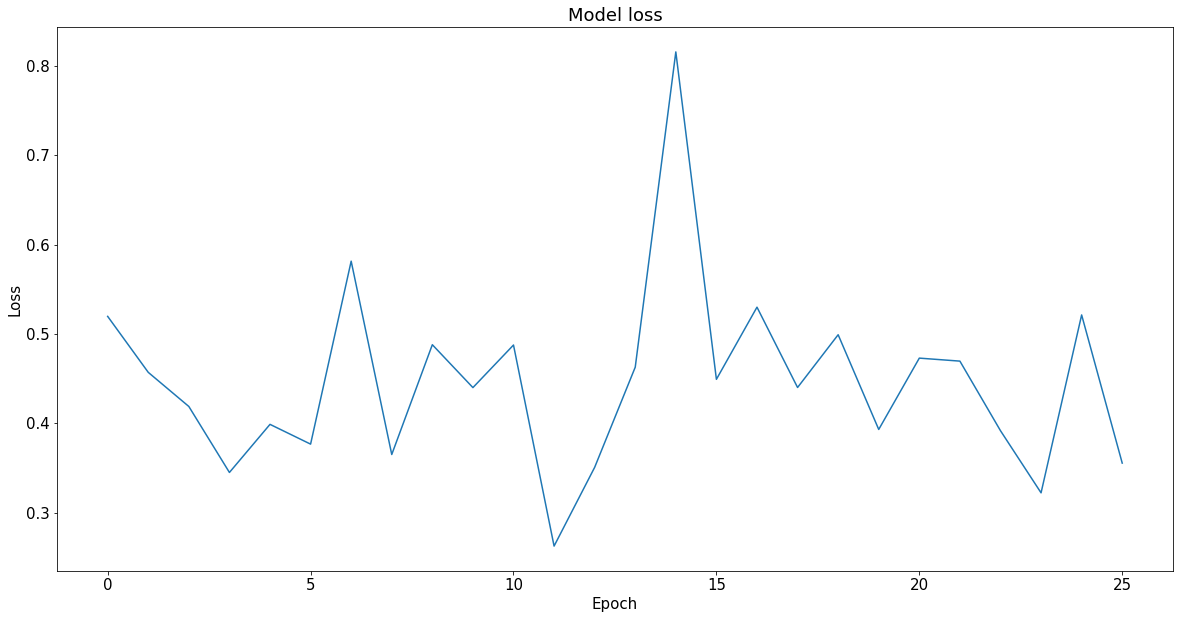

In [17]:
plt.figure(figsize=(20, 10))
plt.rcParams.update({'font.size': 15})
plt.plot(loss_list)
#plt.plot(val_loss)
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
#plt.legend(['Train', 'Val'], loc='upper left')
#plt.savefig('Images/LSTM_Accuracy_Loss.png')

## Pruning

In [30]:
from utils import *
import time
import copy


In [101]:
best_checkpoint = dict()
best_checkpoint['state_dict'] = copy.deepcopy(model.state_dict())
model.load_state_dict(best_checkpoint['state_dict'])
#recover_model()

<All keys matched successfully>

In [106]:
sparsity = 0.5
pruner = FineGrainedPruner(model, sparsity)
pruner.apply(model)
sparse_model_accuracy, _, _ = test_GC(dataloader['test'], model, criterion)
sparse_model_size = get_model_size(model, count_nonzero_only=True)

print(f"{sparsity*100}% sparse model has accuracy={sparse_model_accuracy['acc']:.2f}")
print(f"{sparsity*100}% sparse model has size={sparse_model_size/MiB:.2f} ")

50.0% sparse model has accuracy=0.71
50.0% sparse model has size=0.01 


In [107]:
best_sparse_checkpoint = dict()
best_sparse_accuracy = 0
num_finetune_epochs=10
early_stop_count = 0

for epoch in range(num_finetune_epochs):
  
    acc=[]
    loss_list = []

    for batch in dataloader['train']:
        acc=train(callbacks=[lambda: pruner.apply(model)])        
       
    eval_state = evaluate_GC(dataloader['eval'], model, criterion)
    accuracy=eval_state['acc']
      
    is_best = accuracy > best_sparse_accuracy
    if is_best:
        best_sparse_checkpoint['state_dict'] = copy.deepcopy(model.state_dict())
        best_sparse_accuracy = accuracy
    
    if epoch % 5 == 0:   
        # report train msg
        print(f"Train Epoch:{epoch}  |Loss: {np.average(loss_list):.3f} | "
              f"Acc: {np.concatenate(acc, axis=0).mean():.3f}")
        # report eval msg
        print(f"Eval Epoch: {epoch} | Loss: {eval_state['loss']:.3f} | Acc: {accuracy:.3f}")

Train Epoch:0  |Loss: 0.578 | Acc: 0.760
Eval Epoch: 0 | Loss: 0.525 | Acc: 0.754
Train Epoch:5  |Loss: 0.480 | Acc: 0.780
Eval Epoch: 5 | Loss: 0.495 | Acc: 0.759


In [108]:
test, _, _ = test_GC(dataloader['test'], model, criterion)
sparse_model_accuracy=test['acc']
sparse_model_size = get_model_size(model, count_nonzero_only=True)
print(f"{sparsity*100}% sparse model has accuracy={sparse_model_accuracy:.2f}%")
print(f"{sparsity*100}% sparse model has size={sparse_model_size/MiB:.2f}  ")

50.0% sparse model has accuracy=0.68%
50.0% sparse model has size=0.01  


## Manual Measurement

In [12]:
import statistics as stat

sparsity=0.9
Eva_final=dict()


Base_model_accuracy=[]
T_base_model=[]
Num_parm_base_model=[]
Base_model_size=[]

Pruned_model_accuracy=[]
T_pruned_model=[]
Num_parm_pruned_model=[]
Pruned_model_size=[]

Pruned_finetune_model_accuracy=[]
T_pruned_finetune_model=[]
Num_parm_pruned_finetune_model=[]
Pruned_finetune_model_size=[]

In [24]:
num_epoch=100
Eva=dict()

print(f'Training and evaluation before pruning ')
model = GnnNets(input_dim, output_dim, model_args)
model.to_device()
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=train_args.learning_rate, weight_decay=train_args.weight_decay)
    
for epoch in range(num_epoch):  
    acc=[]
    loss_list = []
    model.train()
    for batch in dataloader['train']:
        acc=train(callbacks=None)        

    eval_state = evaluate_GC(dataloader['eval'], model, criterion)
    accuracy=eval_state['acc']

    if epoch % 20 == 0:   
        # report train msg
        print(f"Train Epoch:{epoch}  |Loss: {np.average(loss_list):.3f} | "
              f"Acc: {np.concatenate(acc, axis=0).mean():.3f}")
        print(f"Eval Epoch: {epoch} | Loss: {eval_state['loss']:.3f} | Acc: {accuracy:.3f}")
    

best_checkpoint = dict()
best_checkpoint['state_dict'] = copy.deepcopy(model.state_dict())
model.load_state_dict(best_checkpoint['state_dict'])
recover_model = lambda: model.load_state_dict(best_checkpoint['state_dict'])

t0=time.time()
test_state, _, _ = test_GC(dataloader['test'], model, criterion)
base_model_accuracy= test_state['acc']
t1=time.time()
t_base_model=t1 - t0
###
base_model_size = get_model_size(model,count_nonzero_only=True)
num_parm_base_model=get_num_parameters(model, count_nonzero_only=True)
###   
print(f"dense model has accuracy on test set={base_model_accuracy:.2f}%")
print(f"dense model has size={base_model_size/MiB:.2f} MiB")
print(f"The time inference of base model is ={t_base_model}") 
print(f"The number of parametrs of base model is:{num_parm_base_model}")   

#Update my Eva dictionary
Eva.update({'base model accuracy': base_model_accuracy,
            'time inference of base model': t_base_model,
            'number parmameters of base model': num_parm_base_model,
            'size of base model': base_model_size})


print('_______________________________________________________')
print(f'Prune the Model and Re-Evaluate the Accuracy')
recover_model()
pruner = FineGrainedPruner(model, sparsity)
pruner.apply(model)


t0=time.time()
test_state, _, _ = test_GC(dataloader['test'], model, criterion)
pruned_model_accuracy= test_state['acc']
t1=time.time()
t_pruned_model=t1 - t0
###
pruned_model_size = get_model_size(model,count_nonzero_only=True)
num_parm_pruned_model=get_num_parameters(model, count_nonzero_only=True)
###   
print(f"{sparsity*100}% sparse model has accuracy on test set={pruned_model_accuracy:.2f}%")
print(f"{sparsity*100}% sparse model has size={pruned_model_size/MiB:.2f} MiB")
print(f"The time inference of {sparsity*100}% sparse model is ={t_pruned_model}") 
print(f"The number of parametrs of {sparsity*100}% sparse model is:{num_parm_pruned_model}")
print(f"{sparsity*100}% sparse model has size={pruned_model_size/MiB:.2f} MiB, "
      f"which is {base_model_size/pruned_model_size:.2f}X smaller than "
      f"the {base_model_size/MiB:.2f} MiB dense model")



#Update my Eva dictionary
Eva.update({'pruned model accuracy': pruned_model_accuracy,
            'time inference of pruned model': t_pruned_model,
            'number parmameters of pruned model': num_parm_pruned_model,
            'size of pruned model': pruned_model_size})



print('_______________________________________________________')
print(f'Finetuning Fine-grained Pruned Sparse Model')

best_sparse_checkpoint = dict()
best_sparse_acc = 0
num_finetune_epochs=100

 
for epoch in range(num_finetune_epochs):
    # At the end of each train iteration, we have to apply the pruning mask
    #    to keep the model sparse during the training
    acc=[]
    loss_list = []

    for batch in dataloader['train']:
        acc=train(callbacks=[lambda: pruner.apply(model)])        

    eval_state = evaluate_GC(dataloader['eval'], model, criterion)
    acc_eval=eval_state['acc']


    is_best = acc_eval > best_sparse_acc
    if is_best:
        best_sparse_checkpoint['state_dict'] = copy.deepcopy(model.state_dict())
        best_sparse_acc = acc_eval

    if epoch % 20 == 0:
         print(f'Epoch {epoch} Sparse Accuracy {acc_eval:.2f}% / Best Sparse Accuracy: {best_sparse_acc:.2f}%')

   

model.load_state_dict(best_sparse_checkpoint['state_dict'])

t0=time.time()
test_state, _, _ = test_GC(dataloader['test'], model, criterion)
pruned_finetune_model_accuracy= test_state['acc']
t1=time.time()
t_pruned_finetune_model=t1 - t0
###
pruned_finetune_model_size = get_model_size(model,count_nonzero_only=True)
num_parm_pruned_finetune_model=get_num_parameters(model, count_nonzero_only=True)
###   
print(f"{sparsity*100}% sparse model has accuracy on test set={pruned_finetune_model_accuracy:.2f}%")
print(f"{sparsity*100}% sparse model has size={pruned_finetune_model_size/MiB:.2f} MiB")
print(f"The time inference of {sparsity*100}% sparse model is ={t_pruned_finetune_model}") 
print(f"The number of parametrs of {sparsity*100}% sparse model is:{num_parm_pruned_finetune_model}")
print(f"{sparsity*100}% sparse model has size={pruned_finetune_model_size/MiB:.2f} MiB, "
      f"which is {base_model_size/pruned_finetune_model_size:.2f}X smaller than "
  f"the {base_model_size/MiB:.2f} MiB dense model")


 #Update my Eva dictionary
Eva.update({'pruned and finetune model accuracy': pruned_finetune_model_accuracy,
            'time inference of pruned and finetune model': t_pruned_finetune_model,
            'number parmameters of pruned and finetune model': num_parm_pruned_finetune_model,
            'size of pruned and finetune model':  pruned_finetune_model_size})



Base_model_accuracy.append(Eva['base model accuracy'])
T_base_model.append(Eva['time inference of base model'])
Num_parm_base_model.append(int(Eva['number parmameters of base model']))
Base_model_size.append(int(Eva['size of base model']))

Pruned_model_accuracy.append(Eva['pruned model accuracy'])
T_pruned_model.append(Eva['time inference of pruned model'])
Num_parm_pruned_model.append(int(Eva['number parmameters of pruned model']))
Pruned_model_size.append(int(Eva['size of pruned model']))

Pruned_finetune_model_accuracy.append(Eva['pruned and finetune model accuracy'])
T_pruned_finetune_model.append(Eva['time inference of pruned and finetune model'])
Num_parm_pruned_finetune_model.append(int(Eva['number parmameters of pruned and finetune model']))
Pruned_finetune_model_size.append(int(Eva['size of pruned and finetune model']))

Training and evaluation before pruning 
Train Epoch:0  |Loss: 0.561 | Acc: 0.750
Eval Epoch: 0 | Loss: 0.547 | Acc: 0.754
Train Epoch:20  |Loss: 0.409 | Acc: 0.823
Eval Epoch: 20 | Loss: 0.401 | Acc: 0.842
Train Epoch:40  |Loss: 0.356 | Acc: 0.858
Eval Epoch: 40 | Loss: 0.370 | Acc: 0.842
Train Epoch:60  |Loss: 0.319 | Acc: 0.868
Eval Epoch: 60 | Loss: 0.330 | Acc: 0.887
Train Epoch:80  |Loss: 0.306 | Acc: 0.871
Eval Epoch: 80 | Loss: 0.375 | Acc: 0.847
dense model has accuracy on test set=0.81%
dense model has size=0.13 MiB
The time inference of base model is =0.11792802810668945
The number of parametrs of base model is:34525
_______________________________________________________
Prune the Model and Re-Evaluate the Accuracy
90.0% sparse model has accuracy on test set=0.45%
90.0% sparse model has size=0.01 MiB
The time inference of 90.0% sparse model is =0.11592936515808105
The number of parametrs of 90.0% sparse model is:3766
90.0% sparse model has size=0.01 MiB, which is 9.17X small

In [26]:
Eva_final=dict()
base_model_accuracy_mean = stat.mean(Base_model_accuracy)
base_model_accuracy_std =  stat.stdev(Base_model_accuracy)
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)

Eva_final.update({'base model accuracy':float(format(base_model_accuracy_mean, '.4f'))})
                 
t_base_model_mean =stat.mean(T_base_model)
#t_base_model_std =t_base_model.std()
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)
Eva_final.update({'time inference of base model':float(format(t_base_model_mean, '.6f'))})

num_parm_base_model_mean = stat.mean(Num_parm_base_model)
#num_parm_base_model_std = num_parm_base_model.std()
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)
Eva_final.update({'number parmameters of base model':num_parm_base_model_mean})

base_model_size_mean = stat.mean(Base_model_size)
#base_model_size_std = base_model_size.std()
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)
Eva_final.update({'base_model_size':base_model_size_mean})

#################################

pruned_model_accuracy_mean =stat.mean(Pruned_model_accuracy)
pruned_model_accuracy_std = stat.stdev(Pruned_model_accuracy)
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)
Eva_final.update({'pruned model accuracy':float(format(pruned_model_accuracy_mean, '.4f'))})
                 

t_pruned_model_mean = stat.mean(T_pruned_model)
#t_base_model_std =t_dence_model.std()
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)
Eva_final.update({'time inference of pruned model':float(format(t_pruned_model_mean, '.6f'))})

num_parm_pruned_model_mean = stat.mean(Num_parm_pruned_model)
#num_parm_base_model_std = num_parm_base_model.std()
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)
Eva_final.update({'number parmameters of pruned model':num_parm_pruned_model_mean})

pruned_model_size_mean =stat.mean( Pruned_model_size)
#base_model_size_std = base_model_size.std()
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)
Eva_final.update({'pruned model size':pruned_model_size_mean})

#################################
pruned_finetune_model_accuracy_mean =stat.mean(Pruned_finetune_model_accuracy)
pruned_finetune_model_accuracy_std = stat.stdev(Pruned_finetune_model_accuracy)
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)
Eva_final.update({'pruned finetune model accuracy':float(format(pruned_finetune_model_accuracy_mean, '.4f'))})
                 

t_pruned_finetune_model_mean =stat.mean(T_pruned_finetune_model)
#t_base_model_std =t_dence_model.std()
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)
Eva_final.update({'time inference of pruned finetune model':float(format(t_pruned_finetune_model_mean,'.6f'))})

num_parm_pruned_finetune_model_mean =stat.mean(Num_parm_pruned_finetune_model)
#num_parm_base_model_std = num_parm_base_model.std()
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)
Eva_final.update({'number parmameters of pruned finetune model':num_parm_pruned_finetune_model_mean})

pruned_finetune_model_size_mean = stat.mean(Pruned_finetune_model_size)
#base_model_size_std = base_model_size.std()
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)
Eva_final.update({'pruned finetune model size':pruned_finetune_model_size_mean})


#################################


print(f"All measurement about pruning process of sparsity:{sparsity*100}% ")   
Eva_final

All measurement about pruning process of sparsity:90.0% 


{'base model accuracy': 0.8263,
 'time inference of base model': 0.119807,
 'number parmameters of base model': 34529.2,
 'base_model_size': 1104934.4,
 'pruned model accuracy': 0.46,
 'time inference of pruned model': 0.116422,
 'number parmameters of pruned model': 3770.2,
 'pruned model size': 120646.4,
 'pruned finetune model accuracy': 0.8244,
 'time inference of pruned finetune model': 0.11975,
 'number parmameters of pruned finetune model': 3770.2,
 'pruned finetune model size': 120646.4}

In [27]:
BBBP_90={'base model accuracy': 0.8263,
 'time inference of base model': 0.119807,
 'number parmameters of base model': 34529.2,
 'base_model_size': 1104934.4,
 'pruned model accuracy': 0.46,
 'time inference of pruned model': 0.116422,
 'number parmameters of pruned model': 3770.2,
 'pruned model size': 120646.4,
 'pruned finetune model accuracy': 0.8244,
 'time inference of pruned finetune model': 0.11975,
 'number parmameters of pruned finetune model': 3770.2,
 'pruned finetune model size': 120646.4}